# ECON 470 Homework 3.1
## Claire Hamilton

In [1]:
# Load packages

suppressPackageStartupMessages({
  library(tidyverse)
})

In [2]:
# Check data

ma.full <- read_csv("../data/output/ma-full.csv", show_col_types = FALSE)

glimpse(ma.full)

Rows: 439,149
Columns: 110
$ contractid          <chr> "H0084", "H0084", "H0084", "H0084", "H0084", "H008…
$ planid              <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ fips                <dbl> 48029, 48037, 48039, 48047, 48067, 48071, 48085, 4…
$ n_nonmiss           <dbl> 10, 10, 11, 0, 8, 0, 10, 0, 11, 9, 6, 0, 4, 10, 9,…
$ avg_enrollment      <dbl> 36.70000, 19.40000, 26.45455, NA, 15.75000, NA, 15…
$ sd_enrollment       <dbl> 12.5082195, 2.0110804, 4.1319157, NA, 1.0350983, N…
$ min_enrollment      <dbl> 19, 17, 20, NA, 14, NA, 13, NA, 39, 13, 14, NA, 13…
$ max_enrollment      <dbl> 55, 23, 33, NA, 17, NA, 18, NA, 91, 38, 18, NA, 17…
$ first_enrollment    <dbl> 19, 18, 20, NA, 14, NA, 13, NA, 39, 13, 14, NA, 13…
$ last_enrollment     <dbl> 55, 21, 33, NA, 17, NA, 18, NA, 91, 37, 18, NA, 17…
$ state               <chr> "TX", "TX", "TX", "TX", "TX", "TX", "TX", "TX", "T…
$ county              <chr> "Bexar", "Bowie", "Brazoria", "Brooks", "Cass", "C…
$ org_type   

# Summarize the Data

## Question 1

In [3]:
# Calculate market share
ma_shares <- ma.full %>%
  group_by(fips, county, year) %>%
  mutate(
    total_ma_enrollment = first(avg_enrolled),
    ma_share = if_else(
      total_ma_enrollment > 0,
      avg_enrollment / total_ma_enrollment,
      NA_real_
    )
  ) %>%
  ungroup()

# Collapse to plan-year level
plan_year <- ma_shares %>%
  group_by(year, contractid, planid) %>%
  summarize(
    Star_Rating = first(Star_Rating),
    avg_enrollment = first(avg_enrollment),
    ma_share = mean(ma_share, na.rm = TRUE),
    .groups = "drop"
  )

# Summary table
summary_table <- plan_year %>%
  filter(year >= 2010 & year <= 2015) %>%
  group_by(year) %>%
  summarize(
    `Mean Star Rating` = round(mean(Star_Rating, na.rm = TRUE), 2),
    `Mean Enrollment` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(ma_share, na.rm = TRUE), 4),
    `Number of Plans` = n(),
    .groups = "drop"
  )

summary_table

year,Mean Star Rating,Mean Enrollment,Mean Market Share,Number of Plans
<dbl>,<dbl>,<dbl>,<dbl>,<int>
2010,3.30,733.20,0.0484,2527
2011,3.45,815.80,0.0637,2160
2012,3.50,882.96,0.0634,2154
2013,3.61,848.66,0.0621,2272
2014,3.84,925.62,0.0606,2256
2015,3.90,1077.17,0.0608,2241


## Question 2

In [4]:
# Question 2

summary_no_stars <- plan_year %>%
  filter(
    year >= 2010 & year <= 2015,
    is.na(Star_Rating)
  ) %>%
  group_by(year) %>%
  summarize(
    `Mean Enrollment` = round(mean(avg_enrollment, na.rm = TRUE), 2),
    `Mean Market Share` = round(mean(ma_share, na.rm = TRUE), 4),
    `Number of Plans` = n(),
    .groups = "drop"
  )

summary_no_stars

year,Mean Enrollment,Mean Market Share,Number of Plans
<dbl>,<dbl>,<dbl>,<int>
2010,231.55,0.0404,964
2011,259.15,0.0535,649
2012,222.41,0.0403,494
2013,195.28,0.0323,409
2014,384.31,0.0294,489
2015,634.33,0.0244,533


## Question 3

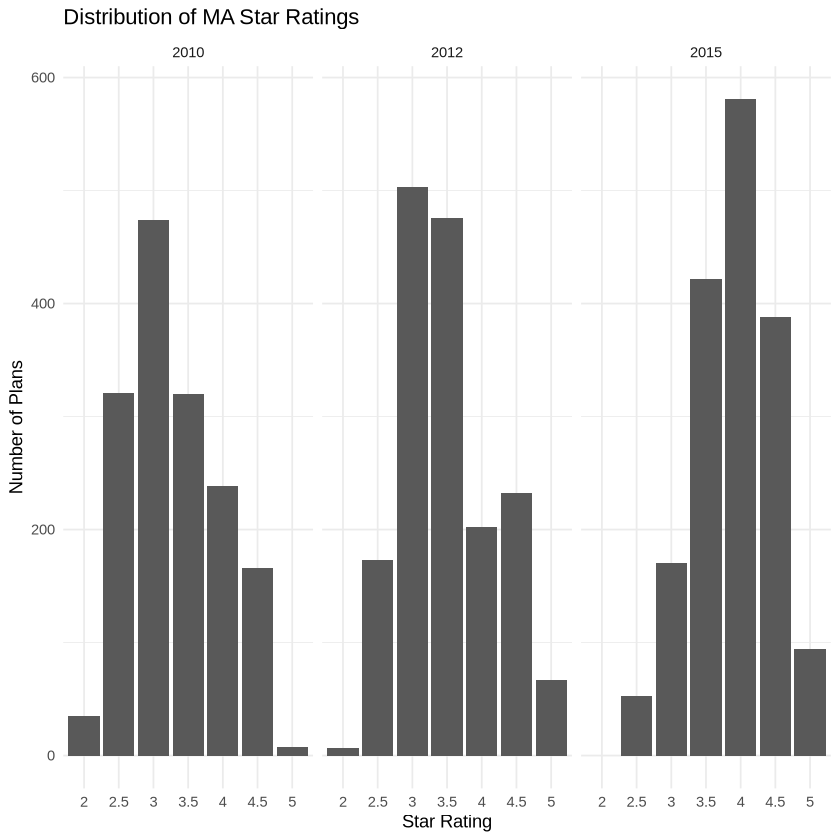

In [5]:
# Question

# Filter

stars_dist <- plan_year %>%
  filter(
    year %in% c(2010, 2012, 2015),
    !is.na(Star_Rating)
  )

# Bar graph

ggplot(stars_dist, aes(x = factor(Star_Rating))) +
  geom_bar() +
  facet_wrap(~year) +
  labs(
    title = "Distribution of MA Star Ratings",
    x = "Star Rating",
    y = "Number of Plans"
  ) +
  theme_minimal()

The distribution of star ratings has shifted to the right over time.

## Question 4

In [6]:
# Question 4

# Indicator variables

plan_year <- plan_year %>%
  mutate(
    star_3   = as.integer(Star_Rating == 3),
    star_35  = as.integer(Star_Rating == 3.5),
    star_4   = as.integer(Star_Rating == 4),
    star_45p = as.integer(Star_Rating >= 4.5)
  )

# Regressions

reg_2010 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2010))

reg_2011 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2011))

reg_2012 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2012))

reg_2013 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2013))

reg_2014 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2014))

reg_2015 <- lm(ma_share ~ star_3 + star_35 + star_4 + star_45p,
               data = filter(plan_year, year == 2015))

# Table

library(stargazer)

stargazer(reg_2010, reg_2011, reg_2012, reg_2013, reg_2014, reg_2015,
          type = "text",
          column.labels = c("2010","2011","2012","2013","2014","2015"),
          covariate.labels = c("3 Stars","3.5 Stars","4 Stars","4.5+ Stars"),
          dep.var.labels = "Market Share",
          omit.stat = c("f","ser"))


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 





                              Dependent variable:                 
             -----------------------------------------------------
                                 Market Share                     
               2010     2011     2012      2013    2014     2015  
               (1)      (2)       (3)      (4)      (5)     (6)   
------------------------------------------------------------------
3 Stars       0.006    0.007    0.0002   0.028***  0.025   0.012  
             (0.005)  (0.009)   (0.009)  (0.009)  (0.022) (0.015) 
                                                                  
3.5 Stars     0.002    0.003   -0.00004  0.037*** 0.046** 0.030** 
             (0.006)  (0.009)   (0.009)  (0.009)  (0.021) (0.014) 
                                                                  
4 Stars       -0.002   -0.012  -0.032***  0.007    0.034   0.027* 
             (0.006)  (0.010)   (0.010)  (0.010)  (0.021) (0.014) 
                                                             

# Estimate ATEs

## Question 5

In [7]:
# Question 5

data.2010 <- read.csv("../data/output/data-2010.csv")

# 1) One row per plan (drop county duplicates FIRST)
data_cleaned <- data.2010 %>%
  distinct(contractid, planid, .keep_all = TRUE) %>%
  ungroup() %>%
  # 2) Calculate the running variable (raw score)
  mutate(
    raw_score = rowMeans(
      as.matrix(select(., breastcancer_screen:ttyt_available)),
      na.rm = TRUE
    ),
    # implied star from raw score: nearest 0.5, with .25 cutoffs (half-up)
    star_from_raw = floor(raw_score * 2 + 0.5) / 2,
    # "rounded up" = star_from_raw is ABOVE the lower half-step
    # (i.e., raw_score is in [s-0.25, s), so it gets bumped to s)
    rounded_up = (star_from_raw > floor(raw_score * 2) / 2)
  )

# 3) Table: number of plans rounded up INTO each rating
rounded_up_table <- data_cleaned %>%
  filter(star_from_raw %in% c(3, 3.5, 4, 4.5, 5)) %>%
  group_by(star_from_raw) %>%
  summarize(
    num_plans_rounded_up = sum(rounded_up, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # ensure all five rows show up even if some are 0
  complete(star_from_raw = c(3, 3.5, 4, 4.5, 5),
           fill = list(num_plans_rounded_up = 0)) %>%
  arrange(star_from_raw) %>%
  rename(Star_Rating = star_from_raw)

rounded_up_table

Star_Rating,num_plans_rounded_up
<dbl>,<int>
3.0,207
3.5,193
4.0,188
4.5,31
5.0,2


## Question 6

In [8]:
# Question 6

data_cleaned <- data.2010 %>%
  distinct(contractid, planid, .keep_all = TRUE) %>%
  mutate(
    raw_score = rowMeans(select(., breastcancer_screen:ttyt_available), na.rm = TRUE)
  ) %>%
  filter(!is.na(raw_score),
         !is.na(avg_enrollment))

estimate_rd <- function(data, cutoff, bw = 0.125) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw) %>%
    mutate(
      treated = as.integer(raw_score >= cutoff),
      running_centered = raw_score - cutoff
    )

  model <- lm(avg_enrollment ~ treated + running_centered, data = rd)

  tibble(
    cutoff = cutoff,
    estimate = coef(model)["treated"],
    se = summary(model)$coefficients["treated", "Std. Error"]
  )
}

bind_rows(
  estimate_rd(data_cleaned, 3.0),
  estimate_rd(data_cleaned, 3.5)
)

cutoff,estimate,se
<dbl>,<dbl>,<dbl>
3.0,-2202.8193,1533.0897
3.5,118.6624,675.3635


## Question 7

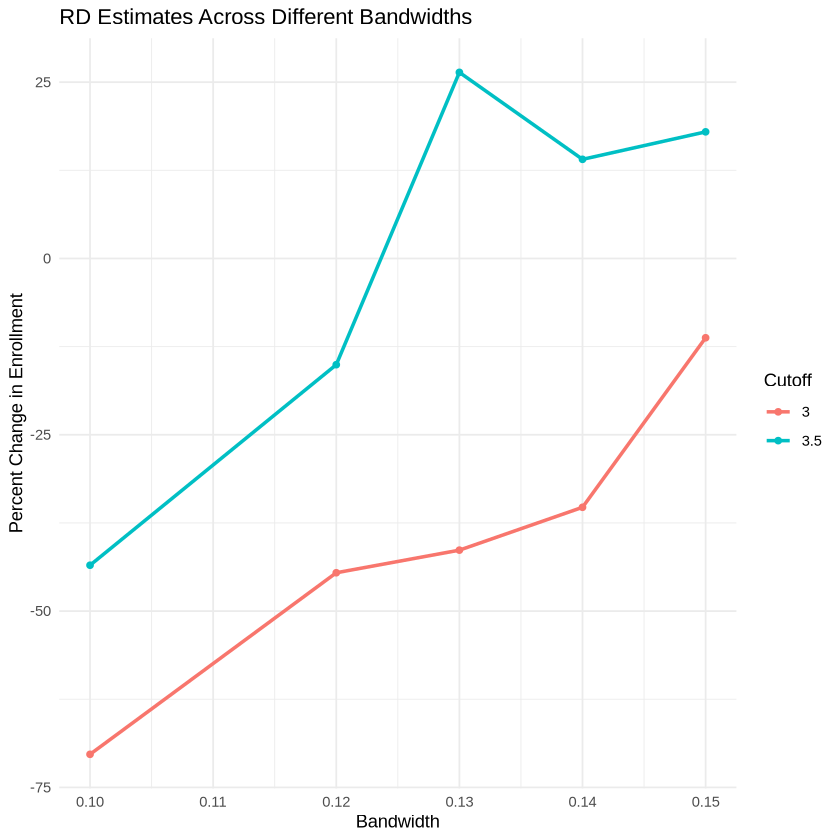

In [11]:
# Question 7

estimate_rd <- function(data, cutoff, bw) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw,
           avg_enrollment > 0) %>%
    mutate(
      treated = as.integer(raw_score >= cutoff),
      running_centered = raw_score - cutoff
    )

  model <- lm(log(avg_enrollment) ~ treated + running_centered, data = rd)

  tibble(
    cutoff = cutoff,
    bandwidth = bw,
    estimate = coef(model)["treated"],
    se = summary(model)$coefficients["treated", "Std. Error"]
  )
}

bandwidths <- c(0.10, 0.12, 0.13, 0.14, 0.15)
cutoffs <- c(3.0, 3.5)

rd_results <- expand.grid(
  cutoff = cutoffs,
  bandwidth = bandwidths
) %>%
  rowwise() %>%
  do(estimate_rd(data_cleaned, .$cutoff, .$bandwidth)) %>%
  ungroup()

rd_results <- rd_results %>%
  mutate(percent_effect = 100 * (exp(estimate) - 1))

ggplot(rd_results, aes(x = bandwidth,
                       y = percent_effect,
                       color = factor(cutoff))) +

  geom_line(linewidth = 1) +
  geom_point() +

  labs(
    title = "RD Estimates Across Different Bandwidths",
    x = "Bandwidth",
    y = "Percent Change in Enrollment",
    color = "Cutoff"
  ) +

  theme_minimal()

My results are quite sensitive to the choice of bandwidth, increasing substantially as the bandwidth increases.

## Question 8

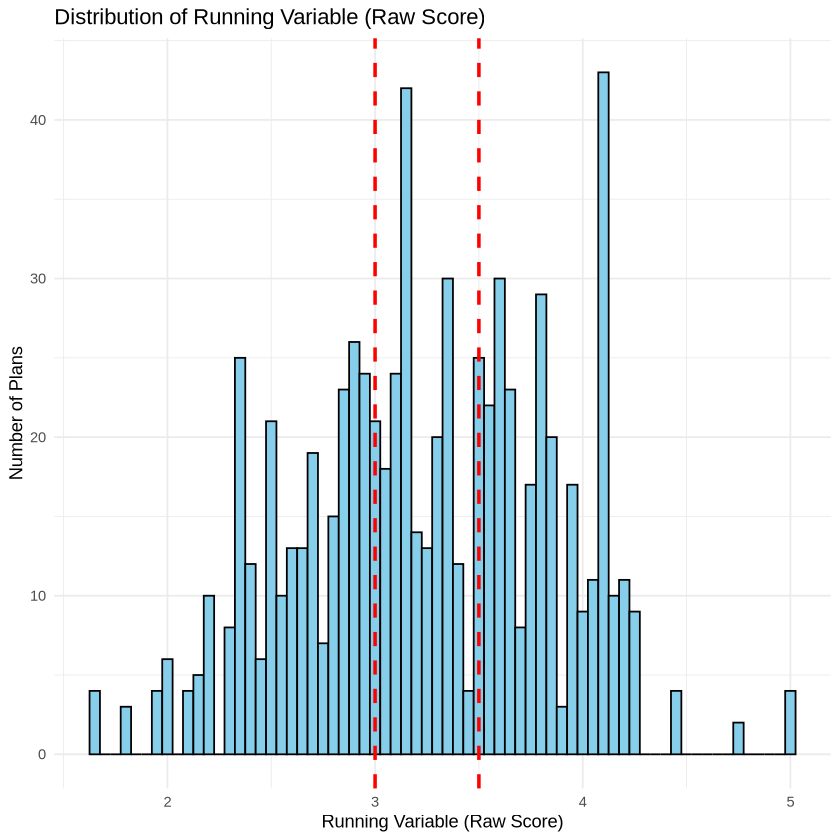

In [13]:
# Question 8

ggplot(data_cleaned, aes(x = raw_score)) +
  geom_histogram(binwidth = 0.05, color = "black", fill = "skyblue") +

  geom_vline(xintercept = c(3.0, 3.5),
             linetype = "dashed",
             color = "red",
             linewidth = 1) +

  labs(
    title = "Distribution of Running Variable (Raw Score)",
    x = "Running Variable (Raw Score)",
    y = "Number of Plans"
  ) +

  theme_minimal()

The distrubution of the running variable does not seem to change meaningfully before vs. after the 3.0 and 3.5 thresholds. 

## Question 9

In [14]:
# Question 9

data_cleaned <- data_cleaned %>%
  mutate(
    HMO = as.integer(grepl("HMO", plan_type)),
    PartD = as.integer(partd == "Yes")
  )

estimate_balance <- function(data, cutoff, bw = 0.125, outcome) {

  rd <- data %>%
    filter(raw_score >= cutoff - bw,
           raw_score <= cutoff + bw) %>%
    mutate(
      treated = as.integer(raw_score >= cutoff),
      running_centered = raw_score - cutoff
    )

  model <- lm(as.formula(paste(outcome, "~ treated + running_centered")), data = rd)

  tibble(
    cutoff = cutoff,
    outcome = outcome,
    estimate = coef(model)["treated"],
    se = summary(model)$coefficients["treated", "Std. Error"]
  )
}

balance_results <- bind_rows(
  estimate_balance(data_cleaned, 3.0, outcome = "HMO"),
  estimate_balance(data_cleaned, 3.5, outcome = "HMO"),
  estimate_balance(data_cleaned, 3.0, outcome = "PartD"),
  estimate_balance(data_cleaned, 3.5, outcome = "PartD")
)

balance_results

cutoff,outcome,estimate,se
<dbl>,<chr>,<dbl>,<dbl>
3.0,HMO,-0.19871579,0.1627513
3.5,HMO,-0.23686344,0.1768346
3.0,PartD,0.08526642,0.1430082
3.5,PartD,0.08854949,0.1712352


The plans before vs. after the thresholds are not statistically significantly different from one another. 

## Question 10

Based on my current analysis, it seems that increasing a star rating does not significantly affect MA enrollments. However, my findings were very sensitive to the choice of bandwidth, with larger bandwidths increasing the estimated treatment effect. I am still working on the code for my regression because the large negative estimate for the 3.0 plans does not seem realistic, so I plan to work on revising my code to see if the results change.